In [3]:
import casadi as ca
import numpy as np

import matplotlib.pyplot as plt

# Bioreaktor Model: 

Es handelt sich um ein einfaches Modell eines kontinuierlich betriebenen Rührkesselreaktors (CSTR) für die Kultivierung von Mikroorganismen. Das Modell umfasst die folgenden Hauptkomponenten:

1. **Zustandsvariablen:**
   - Biomassekonzentration ($X$) [g/L]
   - Substratkonzentration ($S$) [g/L]
   - Reaktorvolumen ($V$) [L]

2. **Parameter:**
   - Maximale spezifische Wachstumsrate ($\mu_{max}$) [1/h]
   - Halbgesättigte Substratkonzentration ($K_s$) [g/L]
   - Substratkonzentration im Zulauf ($S_{in}$) [g/L]
   - Ausbeute ($Y$) [g Biomasse/g Substrat]

3. **Eingangsgrößen:**
   - Flowrate der Substratlösung ($F_{in}$) [L/h]
   - Flowrate des Reaktors ($F_{out}$) [L/h]
   - Steuergröße ($U$) [g/L/h] (z.B. zusätzliche Substratzzufuhr)

4. **Dynamische Gleichungen:**
   $$ \frac{d (V \cdot X)}{dt} =  V f_{reac}(X,S) - F_{out} X $$
   $$ \frac{d (V \cdot S)}{dt} =  - V f_{reac}(X,S) + F_{in} S_{in} - F_{out} S $$
   $$ \frac{d V}{dt} = F_{in} - F_{out} $$

Gleichung 1 beschreibt das Wachstum der Biomasse, während Gleichung 2 die Veränderung der Substratkonzentration im Reaktor darstellt.


In [12]:
# Bioreactor parameters
Sin = 2.0 # Substratkonzentration

F_in = 1.0 # Flowrate der Substratlösung [L/h]
F_out = 1.0 # Flowrate des Reaktors [L/h]

# Zustandsvariablen definieren
X = ca.SX.sym('X') # Zellkonzentration
S = ca.SX.sym('S') # Substratkonzentration
V = ca.SX.sym('V') # Reaktorvolumen

# Zustandsvektor
states = ca.vertcat(X, S, V)

V_save = ca.fmax(V, 0.1)  # Verhindere Division durch zu kleine Werte

dV_dt = F_in - F_out
#  d V x/dt =  dV/dt x + V dx/dt  => dx/dt = (d (V x)/dt - dV/dt x) / V
dx_dt = (- F_out * X - dV_dt * X) / V_save
#  d V s/dt =  dV/dt s + V ds/dt  => ds/dt = (d (V s)/dt - dV/dt s) / V
ds_dt = ( F_in * Sin - F_out * S - dV_dt * S) / V_save 

# Zustandsraummodell
f = ca.vertcat(dx_dt, ds_dt, dV_dt)


In [13]:
# Simulation erstellen

dt = 0.1 # Zeitschritt
T = 20.0 # Simulationsdauer


# Anfangsbedingungen
X0 = 1.0
S0 = 2.0
V0 = 10.0
U_const = 0.0

# Integrator erstellen
integrator = ca.integrator('integrator', 'rk', {'x': states, 'ode': f}, {'tf': dt})

# Simulation durchführen
time = np.arange(0, T, dt)
X_sim = [X0]
S_sim = [S0]
V_sim = [V0]

for t in time[1:]:
    res = integrator(x0=ca.vertcat(X_sim[-1], S_sim[-1], V_sim[-1]))
    X_sim.append(float(res['xf'][0]))
    S_sim.append(float(res['xf'][1]))
    V_sim.append(float(res['xf'][2]))


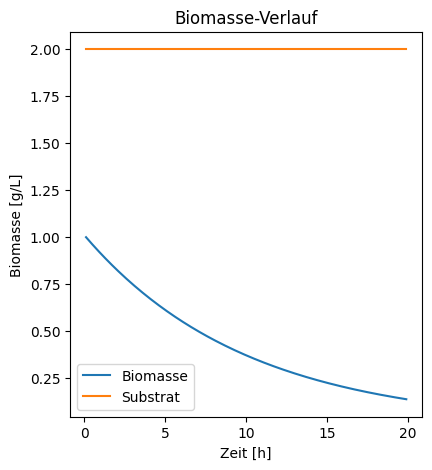

In [14]:

# Plotten
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(time[1:], X_sim[:-1], label='Biomasse')
plt.plot(time[1:], S_sim[:-1], label='Substrat')
plt.xlabel('Zeit [h]')
plt.ylabel('Biomasse [g/L]')
plt.title('Biomasse-Verlauf')
plt.legend()
plt.show()